# 3. Local hotspots of interaction

Notebooks 01 and 02 both return one number per cell type pair. Neither tells you *where*
in the tissue an interaction is happening — a cell type pair can be strongly coupled in
one anatomical region and silent everywhere else.

The **inflow score** works per cell. It quantifies how much a given cell is *influenced*
by neighboring ligand-producing cells through **spatial weighting** of ligand and receptor
expression. This captures both the **directionality** and **locality** of intercellular
signaling, giving a fine-grained view of communication "flows".

$$
\text{Inflow}_{i,s,\ell,r} =
\left(
\frac{
\sum_{j=1}^{n} W_{ij}\,L_{j,\ell}\,C_{j,s}
}{
\sum_{j=1}^{n} W_{ij}
}
\right)
R_{i,r}
$$

where:

- $W_{ij}$ — spatial connectivity weight between target cell *i* and neighboring cell *j*.
- $L_{j,\ell}$ — expression of ligand $\ell$ in cell *j*.
- $C_{j,s}$ — hard filter, 1 if cell *j* belongs to cell type *s*, otherwise 0.
- $R_{i,r}$ — expression of receptor *r* in target cell *i*.
- $n$ — total number of cells.

In other words, the inflow score measures how strongly a cell is **receiving** ligand
signals from its spatial neighborhood, accounting for both spatial proximity and cell-type
context.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import plotnine as p9

import squidpy as sq
import liana as li

import warnings
warnings.filterwarnings("ignore")

adata = sc.read_h5ad("data/brain_section.h5ad")
adata

AnnData object with n_obs × n_vars = 51539 × 1120
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'cell_type_colors', 'citation', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap'
    layer

## Calculate the spatial connectivity matrix $W_{ij}$

Before calculating the inflow score, we first need to define the **spatial connectivity
matrix** $W_{ij}$, which encodes how strongly each cell $i$ is connected to its spatial
neighbors $j$. In essence, $W_{ij}$ determines the *neighborhood* over which ligand
signals are integrated — it specifies *who can talk to whom* in the tissue space.

### Choosing the right bandwidth

To compute $W_{ij}$, we typically use a **spatial kernel** (e.g. Gaussian) with a parameter
called the **bandwidth** ($\sigma$), which controls the spatial scale of interactions:

- A **small bandwidth** captures only very **local** interactions (e.g. direct cell–cell contacts).
- A **large bandwidth** allows **broader** neighborhoods, integrating ligand signals from more distant cells.

Choosing the right bandwidth is therefore crucial:
- **Biologically**, it should reflect the *typical range of molecular signaling* in the tissue.
  Some ligands act only on adjacent cells (juxtacrine or short-range paracrine), while
  others diffuse more broadly through the extracellular space.
- **Technically**, the optimal bandwidth also depends on the **spatial resolution**. <br>
    Because the inflow score works at **single-cell resolution**, too wide a bandwidth
    blurs fine spatial patterns, whereas too narrow a bandwidth might miss biologically
    relevant signaling gradients.

`li.pp.query_bandwidth()` lets you explore how many neighbors each cell would have at each
scale — the trade-off between **spatial resolution** and **neighborhood size**.

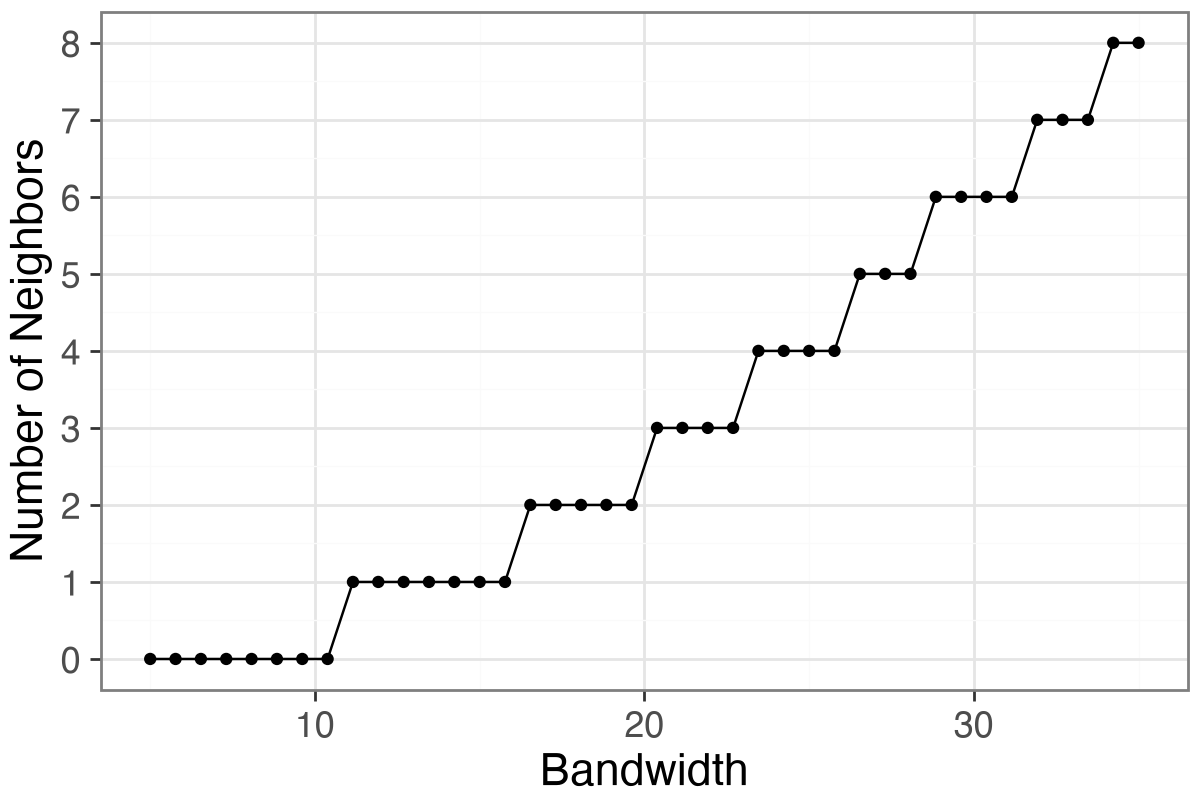

In [2]:
plot, df = li.pp.query_bandwidth(
    coordinates=adata.obsm["X_spatial_coords"],
    start=5,
    end=35,
    interval_n=40
)
plot + p9.scale_y_continuous(breaks=range(int(df.neighbours.min()),
                                       int(df.neighbours.max())+1))

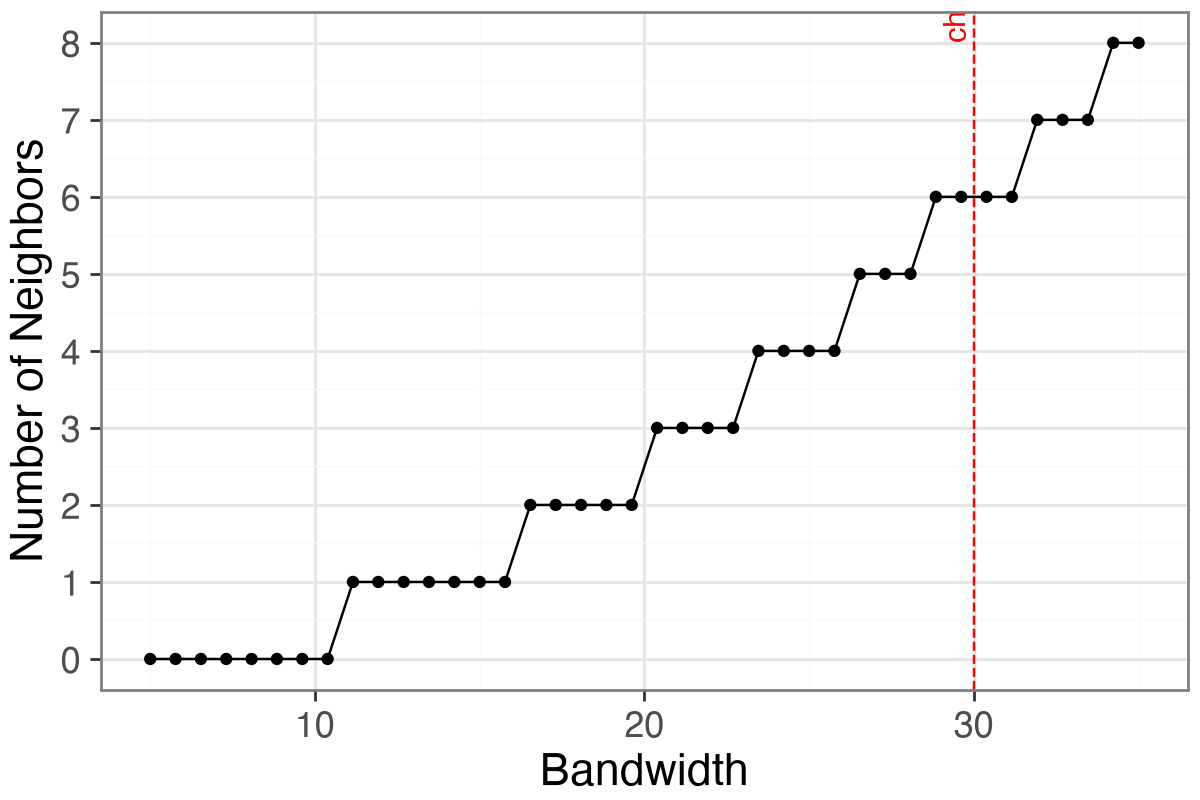

In [3]:
bandwidth = 30
plot + p9.geom_vline(xintercept=bandwidth, linetype="dashed", color="red") + \
       p9.annotate("text", x=bandwidth, y=df.neighbours.max(),
                label=f"chosen={bandwidth}µm",
                angle=90, va="bottom", ha="right", color="red") + \
       p9.scale_y_continuous(breaks=range(int(df.neighbours.min()),
                                       int(df.neighbours.max())+1))

Use the chosen bandwidth to compute the final spatial connectivity matrix $W_{ij}$.

In [4]:
li.pp.spatial_neighbors(adata=adata, bandwidth=bandwidth, spatial_key="X_spatial_coords")

#### Visualize proximity

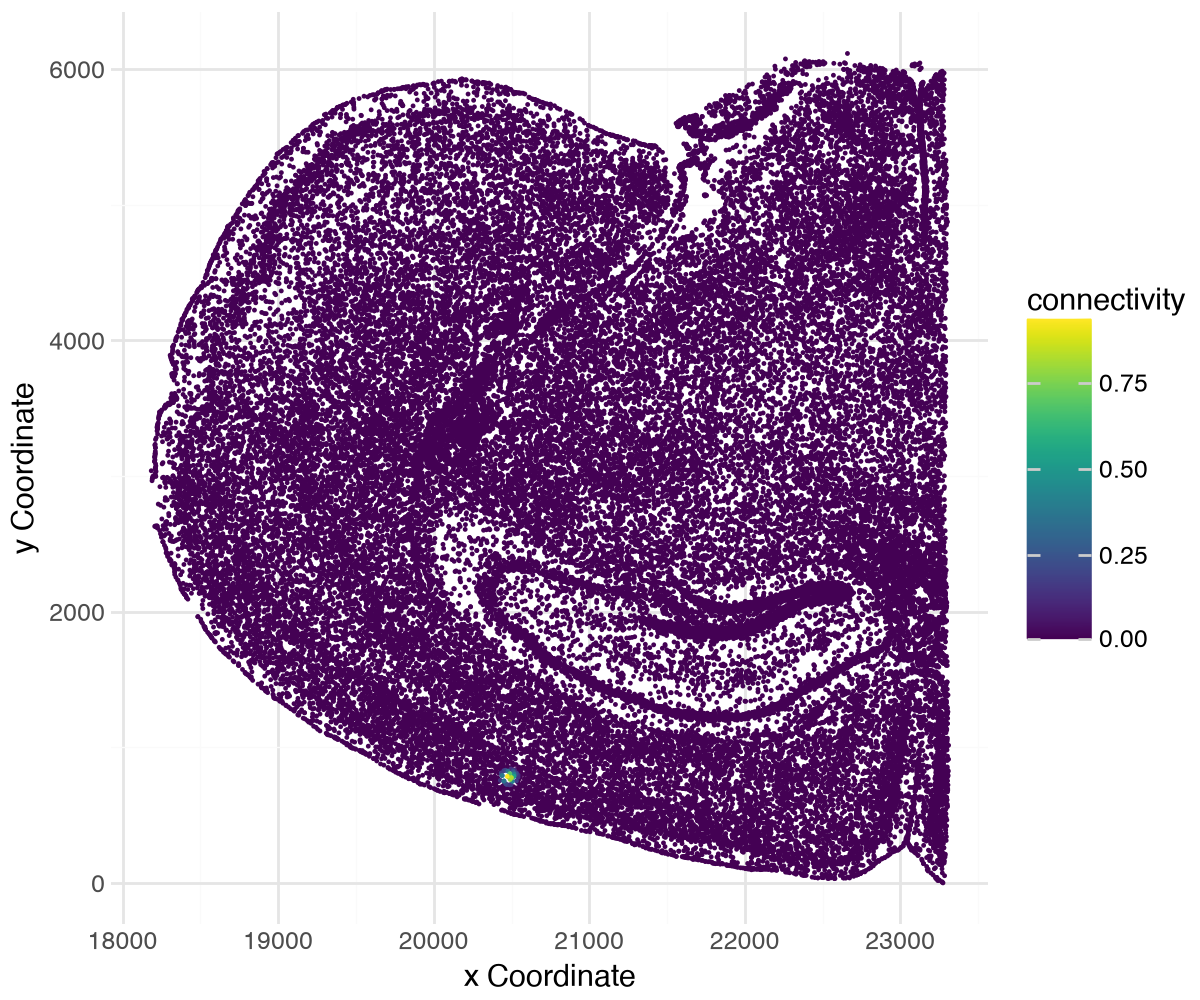

In [5]:
li.pl.connectivity(adata, idx=5500, size=0.01, figure_size=(6, 5), spatial_key="X_spatial_coords")

## Filter to spatially variable genes (SVGs)

The inflow score is computed for every (sender cell type × ligand × receptor) combination,
which is a lot of columns. Restricting to genes with spatial structure — measured by
Moran's I — keeps the output interpretable and the computation cheap. Genes with no
spatial pattern cannot produce a spatial hotspot anyway.

In [6]:
sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False, show_progress_bar=True)

In [7]:
adata.uns['moranI']
#I: Moran's I score for each gene
#pval: p-value (if permutation test is used)
#var_norm: Variance used to normalize Moran's I (used internally for significance).
#pval_norm_fdr_bh: FDR-adjusted p-value (Benjamini-Hochberg correction) for multiple testing.

,I,pval_norm,var_norm,pval_norm_fdr_bh
Slc17a7,0.538179,0.000000,0.000002,0.000000
Neurod2,0.517479,0.000000,0.000002,0.000000
Zic1,0.473927,0.000000,0.000002,0.000000
Clic6,0.467843,0.000000,0.000002,0.000000
Slc30a3,0.459351,0.000000,0.000002,0.000000
...,...,...,...,...
Ccdc192,0.000705,0.308923,0.000002,0.309475
Vsx2,0.000450,0.373264,0.000002,0.373598
Dmbx1,-0.000061,0.488612,0.000002,0.488612
Pax8,-0.000954,0.259932,0.000002,0.260864


In [8]:
## Check how many spatially variable genes (SVGs)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
len(svgs)

1021

In [9]:
adata = adata[:, svgs]

## Compute the inflow score

In [10]:
resource = li.rs.select_resource('mouseconsensus')

lrdata = li.mt.inflow(adata,
                      groupby='cell_type',
                      resource=resource,
                      # keep the pre-2.0 default; `Ntf3^Ntrk3` inflow is sparse and is masked at the new default of 0.05
                      nz_prop=0.001,
                      use_raw=False)

lrdata.shape

(51539, 1713)

### Optional: keep only spatially variable LR interactions

The same Moran's I filter, now applied to the inflow scores themselves.

In [11]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)

In [12]:
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]
len(svis)

1408

In [13]:
lrdata = lrdata[:,svis]
lrdata.uns['moranI'].sort_values("I").tail(10)

,I,pval_norm,var_norm,pval_norm_fdr_bh
tanycyte^Spp1^S1pr1,0.511287,0.0,0.000002,0.0
neuroblast (sensu Vertebrata)^Efna5^Epha7,0.521449,0.0,0.000002,0.0
neuroblast (sensu Vertebrata)^Efna5^Epha4,0.521713,0.0,0.000002,0.0
glutamatergic neuron^Gnb3^Gabbr2,0.533282,0.0,0.000002,0.0
neuroblast (sensu Vertebrata)^Wnt5a^Epha7,0.543802,0.0,0.000002,0.0
tanycyte^Efna5^Ephb1,0.567570,0.0,0.000002,0.0
glutamatergic neuron^Efna5^Epha4,0.593310,0.0,0.000002,0.0
neuroblast (sensu Vertebrata)^Ntf3^Ntrk3,0.672510,0.0,0.000002,0.0
tanycyte^Wnt5a^Fzd5,0.753979,0.0,0.000002,0.0
glutamatergic neuron^Ntf3^Ntrk3,0.810247,0.0,0.000002,0.0


## Visualizations

**1. Spatial inflow intensity for a single ligand–receptor interaction.** <br>
Here, we focus on a single interaction to illustrate the spatial distribution of inferred
signaling. Specifically, we show signal sourced from **glutamatergic neurons** via the
ligand **Ntf3** and received through the receptor **Ntrk3**. The inflow intensity reflects
the strength of inferred ligand–receptor–mediated signaling at each spatial location.

In [14]:
#Define variables
cell_type_col = "cell_type"
brain_regions = "major_brain_region"
spatial_key = "X_spatial_coords"

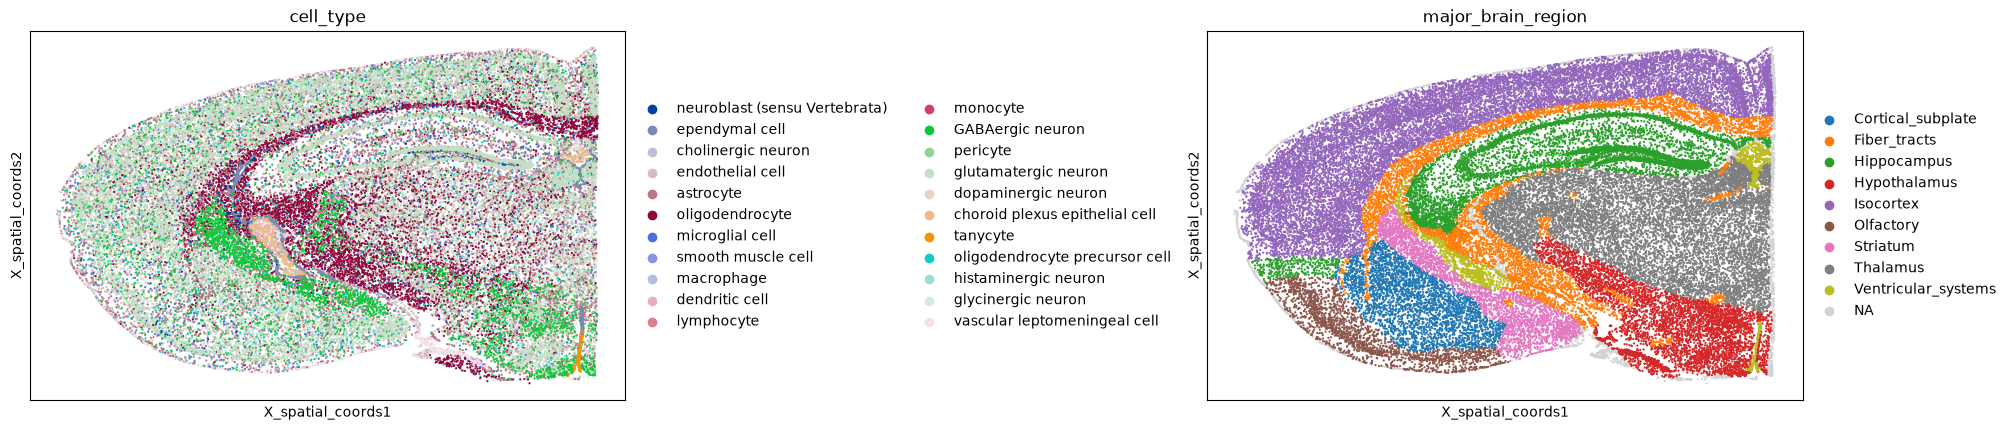

In [15]:
sc.pl.embedding(
    lrdata,
    basis=spatial_key,
    color=[cell_type_col, brain_regions],
    s=10,
    ncols=2,
    cmap="RdBu_r",
    wspace=0.8
)

In [16]:
interaction = 'glutamatergic neuron^Ntf3^Ntrk3'
comp = interaction.split("^")

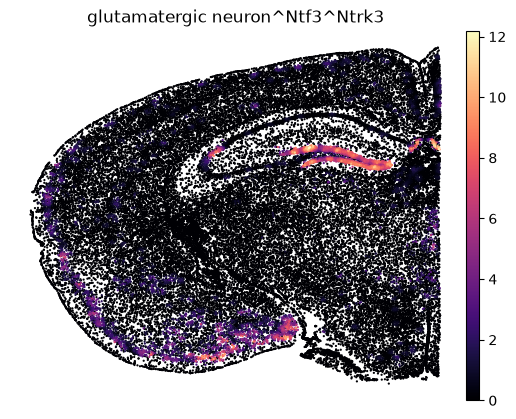

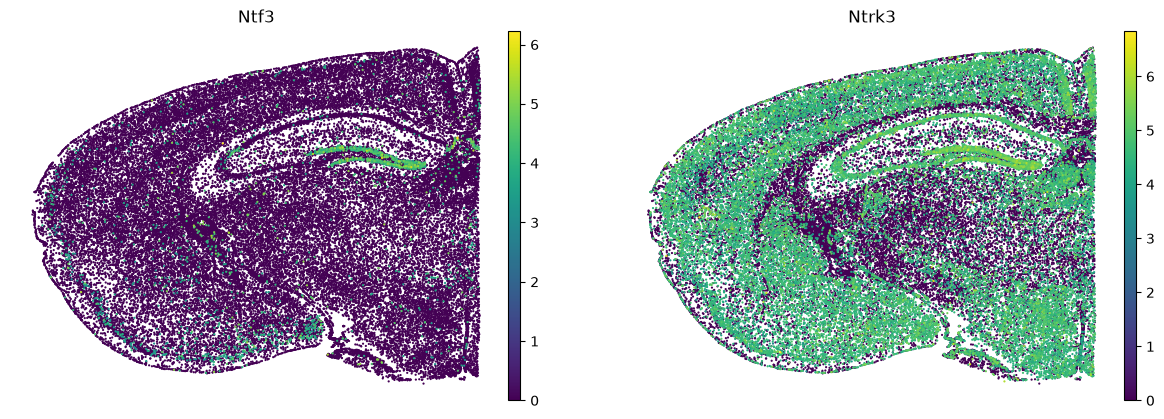

In [17]:
sc.pl.embedding(
    lrdata,
    basis=spatial_key,
    color=interaction,
    s=10,
    ncols=2,
    cmap='magma',
    frameon=False
)

sc.pl.embedding(
    adata,
    basis=spatial_key,
    color=[comp[1], comp[2]],
    s=10,
    use_raw=False,
    ncols=2,
    frameon=False
)

Where are the sender cells themselves?

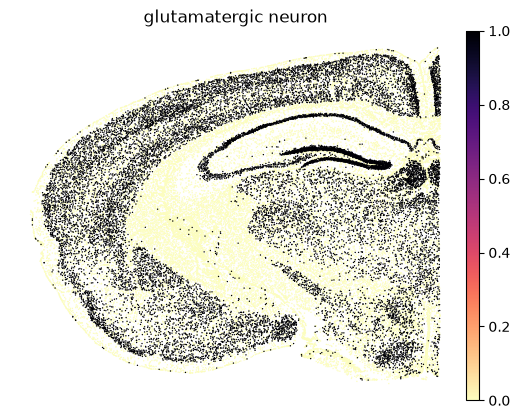

In [18]:
mask = adata.obs[cell_type_col] == 'glutamatergic neuron'
adata.obs['glutamatergic neuron'] = 0
adata.obs.loc[mask, 'glutamatergic neuron'] = 1
sc.pl.embedding(
    adata,
    basis=spatial_key,
    color='glutamatergic neuron',
    s=4,
    use_raw=False,
    ncols=2,
    cmap='magma_r',
    frameon=False
)

**2. Rank cell types receiving inflow from the glutamatergic neuron–Ntf3–Ntrk3 axis.** <br>
Cell types with higher inflow values indicate stronger inferred reception of this
signaling interaction. **Neuroblasts, astrocytes, and GABAergic neurons** show the highest
inflow values.

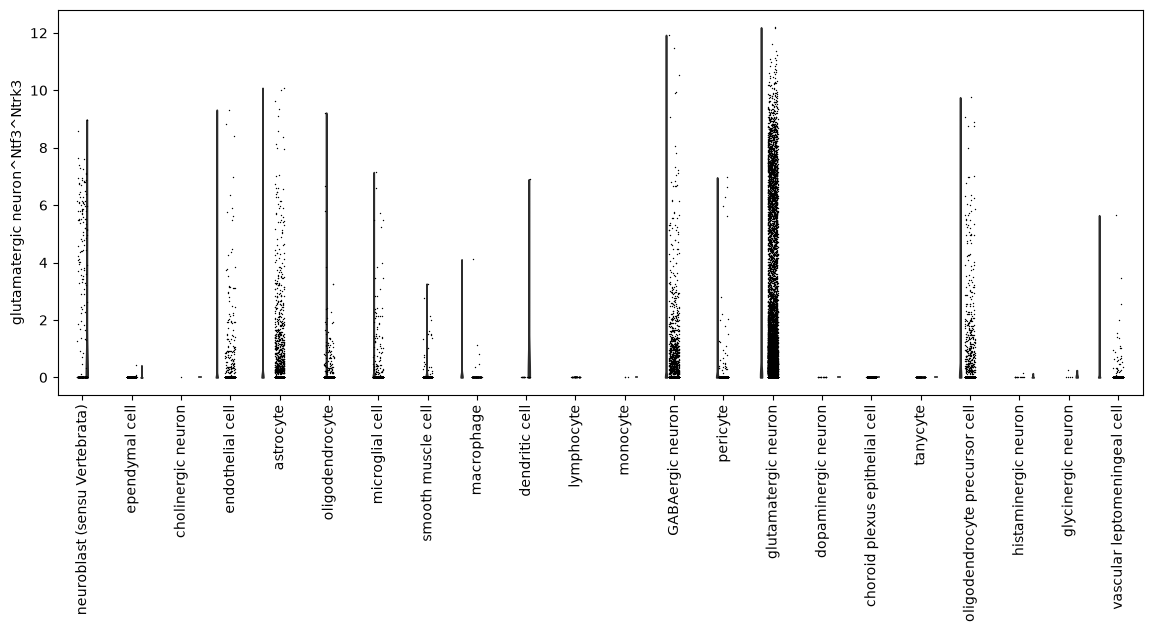

<Figure size 640x480 with 0 Axes>

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))

sc.pl.violin(lrdata, groupby=cell_type_col, keys=interaction, rotation=90, ax=ax)

plt.tight_layout()
plt.show()

**3. Spatial location of the cells receiving the signal.** <br>

Cells are split by cell type, and colour intensity reflects the strength of the inferred
inflow received through the Ntrk3 receptor. <br>

Signaling from glutamatergic neurons via Ntf3 is predominantly received by neuroblasts
(sensu Vertebrata) in the hippocampal region. In contrast, the same signaling axis is
received by GABAergic neurons, astrocytes, and oligodendrocyte precursor cells in the
olfactory and striatal regions. <br>

This is the payoff of a per-cell score: the same interaction has *different receivers in
different places*, which neither a cell type pair ranking nor a g(r) curve can show.

In [20]:
li.pl.feature_by_group(
    adata=lrdata,
    spatial_key=spatial_key,
    feature=interaction,
    groupby=cell_type_col,
    percentile_scaling = (1,97),
    labels=["GABAergic neuron", 'astrocyte', "neuroblast (sensu Vertebrata)", "oligodendrocyte precursor cell"],
    show_counts=False,
    normalize=True,
    figure_size=(10,8)
)

(<Figure size 1000x800 with 5 Axes>,
 <Axes: title={'center': 'glutamatergic neuron^Ntf3^Ntrk3'}>)

## Global summaries

In addition to the high resolution inflow (single-cell level), we can summarize to get
global scores and specificity for each interaction across (receiver) cell types:

In [21]:
li.mt.compute_global_specificity(lrdata, groupby='cell_type',
                                 n_perms=100, verbose=True, use_raw=False)

Running 100 permutations in parallel...
Running permutations: 100%|██████████| 100/100 [00:06<00:00, 16.60it/s]
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    6.4s finished


In [22]:
lrdata.uns['global_interactions'].sort_values("lr_mean", ascending=False).head(3)

,source,ligand_complex,receptor_complex,target,lr_mean,pval
632,choroid plexus epithelial cell,Col18a1,Gpc4,choroid plexus epithelial cell,3.704218,0.009901
105,tanycyte,Efna5,Ephb1,tanycyte,3.511145,0.009901
523,tanycyte,Rspo3,Lgr6,tanycyte,2.334307,0.009901


We can use the global summary to find the cell type pairs that are specific to the **Ntf3 → Ntrk3** axis:

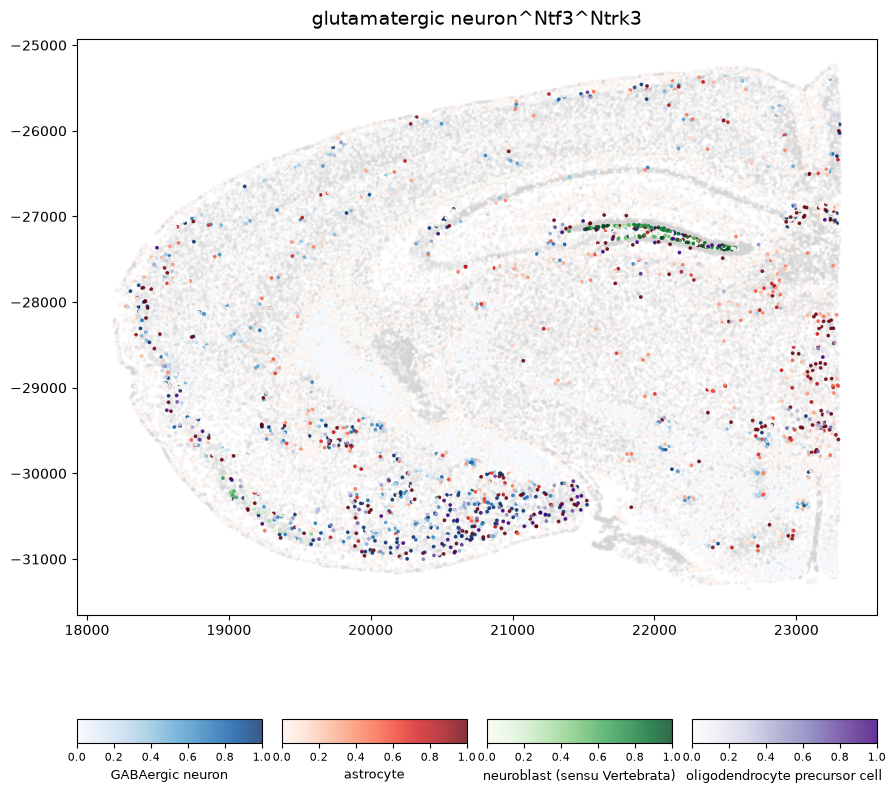

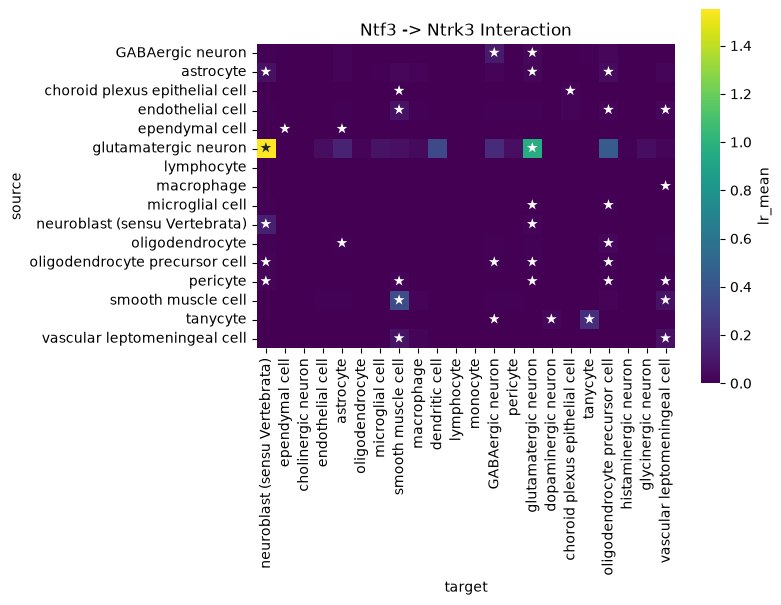

In [23]:
df = lrdata.uns['global_interactions']
interaction_df = df[(df['ligand_complex'] == 'Ntf3') & (df['receptor_complex'] == 'Ntrk3')].copy()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    data= interaction_df.pivot_table(index='source', columns='target', values='lr_mean'),
    annot=interaction_df.pivot(index='source', columns='target', values='pval').map(lambda x: '★' if x < 0.05 else ''),
    fmt='',
    square=True,
    annot_kws={'fontfamily': 'DejaVu Sans'},
    cmap='viridis',
    cbar_kws={'label': 'lr_mean'}
)
plt.title('Ntf3 -> Ntrk3 Interaction')
plt.tight_layout()
plt.show()

We can also identify the top ligand–receptor pairs used by a specific source cell type.
Here we focus again on **glutamatergic neurons** as the signaling source.

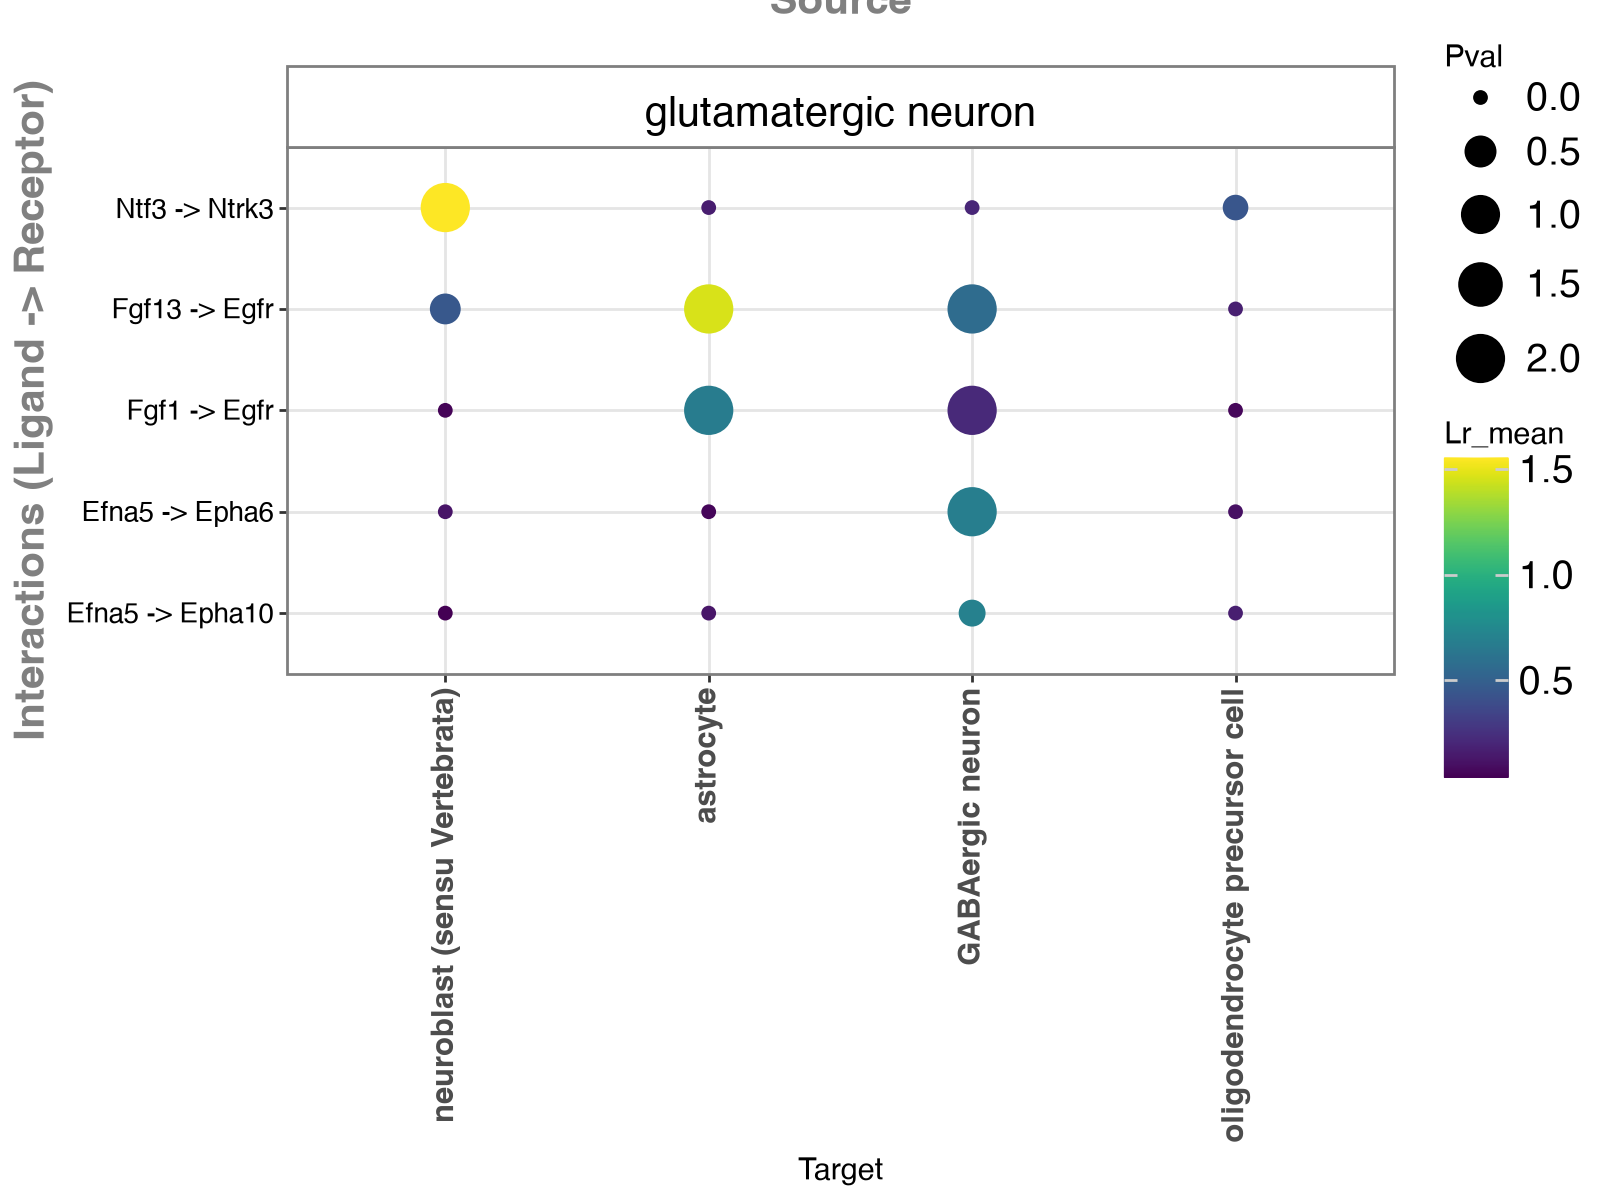

In [24]:
li.pl.dotplot(adata = lrdata,
              colour="lr_mean",
              size ='pval',
              source_labels=["glutamatergic neuron"],
              target_labels=['neuroblast (sensu Vertebrata)', "astrocyte", "oligodendrocyte precursor cell", "GABAergic neuron"],
              filter_fn=lambda x: x['lr_mean'] > 0.5,
              inverse_size=True,
              figure_size=(8,6),
              uns_key='global_interactions'
             )

### Going further

The inflow scores are a cell × interaction matrix, so they can be handed to any method that
takes one. For a worked example — factor analysis on inflow scores to recover
*spatially-resolved communication programmes* — see
[Inflow & MOFA-Flex](https://liana.readthedocs.io/en/stable/tutorials/notebooks/inflow_mofaflex.html).


---

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise 1 — How sharp is a hotspot?**

The `bandwidth` chosen above (30 µm) sets the neighbourhood over which ligand signal is
integrated — and therefore how sharp or how smeared a hotspot looks. As in notebook 01 it
is a distance in microns, here applied per cell rather than per cell type pair.

Recompute `li.pp.spatial_neighbors` and `li.mt.inflow` at `bandwidth=10` and
`bandwidth=100`, and plot the `glutamatergic neuron^Ntf3^Ntrk3` map for each.

Which bandwidth would you trust, and what would you look at to decide?
</div>

In [25]:
for bw in [10, 30, 100]:
    li.pp.spatial_neighbors(adata=adata, bandwidth=bw, spatial_key="X_spatial_coords")
    # ... recompute inflow and plot `interaction`
    print(bw)

10
30
100


<details>
<summary><b>▶ Solution</b></summary>

```python
for bw in [10, 30, 100]:
    li.pp.spatial_neighbors(adata=adata, bandwidth=bw, spatial_key="X_spatial_coords")
    tmp = li.mt.inflow(adata, groupby='cell_type', resource=resource,
                       nz_prop=0.001, use_raw=False)
    tmp.obsm["X_spatial_coords"] = adata.obsm["X_spatial_coords"]
    sc.pl.embedding(tmp, basis=spatial_key, color=interaction, s=10,
                    cmap='magma', frameon=False, title=f"bandwidth={bw} µm")

# restore the chosen bandwidth before continuing
li.pp.spatial_neighbors(adata=adata, bandwidth=bandwidth, spatial_key="X_spatial_coords")
```

At `bandwidth=10` most cells have almost no neighbours, so the map is sparse and noisy —
you are close to plotting receptor expression alone. At `bandwidth=100` the ligand signal
is averaged over a wide neighbourhood and the hippocampal hotspot smears into the
surrounding tissue.

Two things to decide on, rather than eyeballing: the **neighbour count** curve from
`li.pp.query_bandwidth` (you want more than a handful of neighbours, but not hundreds),
and **Moran's I** of the resulting inflow score — a bandwidth that destroys spatial
structure will lower it, and one that over-smooths will inflate it trivially. The
biological prior matters most: 27 µm is roughly one to two cell diameters, appropriate for
short-range paracrine signalling.

</details>

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise 2 — Follow your own interaction**

Pick another interaction — either a different sender cell type for `Ntf3^Ntrk3`, or a
different LR pair entirely — and remake the spatial map and the violin plot.

```python
lrdata.uns['global_interactions'].sort_values("lr_mean", ascending=False).head(20)
```

Does its hotspot line up with an anatomical region in the `major_brain_region` plot?
</div>

In [26]:
# your turn
lrdata.uns['global_interactions'].sort_values("lr_mean", ascending=False).head(20)

,source,ligand_complex,receptor_complex,target,lr_mean,pval
632,choroid plexus epithelial cell,Col18a1,Gpc4,choroid plexus epithelial cell,3.704218,0.009901
105,tanycyte,Efna5,Ephb1,tanycyte,3.511145,0.009901
523,tanycyte,Rspo3,Lgr6,tanycyte,2.334307,0.009901
3319,GABAergic neuron,Gal,Galr1,histaminergic neuron,2.222413,0.009901
2263,GABAergic neuron,Hdc,Hrh3,histaminergic neuron,2.076102,0.009901
80,glutamatergic neuron,Efna5,Epha4,glutamatergic neuron,2.040194,0.009901
4855,glutamatergic neuron,Pdyn,Oprd1,dopaminergic neuron,1.815148,0.009901
3783,vascular leptomeningeal cell,Fn1,Tnfrsf11b,vascular leptomeningeal cell,1.711837,0.009901
26145,vascular leptomeningeal cell,Col6a1,Cd44,dendritic cell,1.616094,0.009901
28655,pericyte,Lama4,Cd44,monocyte,1.585660,0.009901


<details>
<summary><b>▶ Solution</b></summary>

Column names in `lrdata` follow the pattern `"<sender cell type>^<ligand>^<receptor>"`,
so any row of `global_interactions` can be turned into a plot directly:

```python
my_interaction = "choroid plexus epithelial cell^Col18a1^Gpc4"
sc.pl.embedding(lrdata, basis=spatial_key, color=my_interaction,
                s=10, cmap='magma', frameon=False)
```

Most strong interactions do map onto a recognisable region — that is the whole point of a
spatially resolved score. A useful sanity check is to compare against the ligand and
receptor expression maps separately: if the inflow hotspot sits exactly where the receptor
is expressed and pays no attention to where the ligand is, the score is being driven by
receptor expression alone and the "communication" reading is not supported.

</details>

---

## The three questions, side by side

| notebook | question | method | key parameter | what you get |
| --- | --- | --- | --- | --- |
| 01 | Which cell types talk — if they are close enough to? | `rank_aggregate` + `spatial_pair_proximity` | proximity `bandwidth` | one score per cell type pair, zeroed for distant pairs |
| 02 | At what distance does it happen? | `cross_pcf`, `lric` | `radius_step`, `max_radius` | a curve g(r) per interaction, and its peak radius |
| 03 | Where in the tissue does it happen? | `inflow` | kernel `bandwidth` | one score per **cell**, mappable onto the tissue |

All three run on the same section and the same LR resource. They answer different
questions, so they do not have to agree — and where they disagree is usually informative.

Fuller treatments of every method here, plus much more (multi-sample, multi-condition,
downstream networks), are in the [LIANA+ tutorials](https://liana-py.readthedocs.io/en/latest/notebooks/).